# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huzaifaguru/flyrank-ml-internship/blob/main/work/notebooks/w01_research_question.ipynb)

**Provisional lane: Lane 4 — CTR / Engagement Opportunity Scoring.**

> Skills loaded for this assignment: `skills/framing-ml-problems/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`
> (router: `skills/README.md`). Data: `data/raw/content_refresh_anonymized.csv` — 30,000 rows x 44 columns,
> 32 pseudonymized clients, trailing-90-day window. Column reference: `docs/data-dictionary.md`.

Every number below is computed live from the shipped CSV in the cell above it. Nothing is typed in by hand.

## 1. My lane (or freestyle) and why

**Lane 4 — CTR / Engagement Opportunity Scoring.**

> Which already-visible pages capture fewer clicks than comparable pages at the same position,
> and therefore deserve a metadata, snippet, or intent review?

I picked this lane for three reasons.

**It starts where the money is already spent.** A page in Lane 4 has already earned its impressions — the
ranking exists, the demand exists, someone already paid to produce the content. The only thing missing is
the click. That makes the recommended action small and cheap (rewrite a title, fix a meta description,
fix an intent mismatch, add a snippet-friendly block) compared with a full content refresh, so the same
reviewer hour buys more.

**It is not the demo.** `scripts/01`–`05` already build a Lane 2 refresh queue on this exact CSV, scored
against `is_declining_label`. If I choose Lane 2, week 1 starts on a problem the repo has already solved and
my capstone risks becoming a re-run with different hyperparameters. Lane 4 reads the same rows and asks a
different question, so the baseline, the reason codes, and the metric are all mine to build.

**Its target is measured, not defined.** The data dictionary is blunt about the label trap:
`is_declining_label = (trend_direction == "down")`, and `trend_direction` comes from `trend_pct`. That target
is a *definition* someone wrote down, so a model trained on it partly learns the rule. Clicks, impressions,
and average position are *measurements* of what people actually did. Lane 4's quantity of interest is built
out of those, which is the "target must be observed, not defined" rule in `framing-ml-problems`.

**Grain (what one row means):** one pseudonymized content item (a page) belonging to one pseudonymized
client, summarised over a trailing 90-day window. Not a client, not a day, not a keyword — a page.
`content_id` and `client_id` are pseudonyms: I use `client_id` for grouped splits and never as a feature.

In [1]:
# --- Setup: works in Colab and locally, from repo root or from work/notebooks/ ---
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/huzaifaguru/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
CSV_REL  = "data/raw/content_refresh_anonymized.csv"

if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    # walk up from work/notebooks/ (or wherever) until the repo root is under us
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / CSV_REL).exists():
            os.chdir(candidate)
            break

CSV = Path(CSV_REL)
assert CSV.exists(), f"starter CSV not found from {Path.cwd()} - run this from the repo"
print("Repo root :", Path.cwd())
print("Data file :", CSV)

Repo root : /tmp/flyrank
Data file : data/raw/content_refresh_anonymized.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(CSV)

print(f"rows x columns      : {df.shape[0]:,} x {df.shape[1]}")
print(f"pseudonymized clients: {df['client_id'].nunique()}")
print(f"unique pages         : {df['content_id'].nunique():,}  (grain check: one row = one page)")
print(f"duplicate content_id : {df['content_id'].duplicated().sum()}   <- must be 0 for my grain to hold")
print()
print("Columns Lane 4 leans on:")
for c in ["impressions_90d", "clicks_90d", "ctr", "avg_position", "position_tier",
          "impression_tier", "sessions_90d", "engagement_rate", "main_intent", "content_type"]:
    print(f"  {c:18s} dtype={str(df[c].dtype):8s} missing={df[c].isna().sum():>6,}")

rows x columns      : 30,000 x 44
pseudonymized clients: 32
unique pages         : 30,000  (grain check: one row = one page)
duplicate content_id : 0   <- must be 0 for my grain to hold

Columns Lane 4 leans on:
  impressions_90d    dtype=int64    missing=     0
  clicks_90d         dtype=int64    missing=     0
  ctr                dtype=float64  missing=     0
  avg_position       dtype=float64  missing=     0
  position_tier      dtype=str      missing=     0
  impression_tier    dtype=str      missing=     0
  sessions_90d       dtype=int64    missing=     0
  engagement_rate    dtype=float64  missing=     0
  main_intent        dtype=str      missing= 2,374
  content_type       dtype=str      missing=     0


## 2. The question: decision, action, cost of a wrong call

### The decision
A content reviewer has a fixed number of hours this week and an inventory far larger than those hours.
The decision is not "is this page good?" — it is **"which pages do I open first?"** My work improves the
order of that queue.

### The output
A **ranked review queue**: one row per page, carrying a position- and volume-adjusted opportunity score,
a suggested action, human-readable reason codes (e.g. *high impressions*, *strong position*,
*CTR well below tier peers*, *enough volume to trust*), and a confidence label. A reviewer can read any row
and see why it is there — a score with no reason code is not a decision aid, it is a black box someone will
ignore by week three.

### Who acts, and what they do
A content/SEO reviewer opens the top of the queue and takes a **small** action: rewrite the title tag or
meta description, fix an intent mismatch between what the page answers and what the query wants, restructure
the opening so it reads well as a snippet, or mark the page "monitor, not enough volume." No action here
requires rewriting the article, which is exactly why the lane is attractive.

### The cost of a wrong recommendation
Three costs, in increasing order of how much they should scare me:

1. **A wasted reviewer hour.** A page rises to the top, someone opens it, and there is nothing wrong.
2. **The opportunity cost of the slot it stole.** Worse than (1): a genuinely under-performing page sat at
   rank 60 and never got looked at. Ranking is zero-sum in a capacity-limited queue.
3. **A harmful edit.** A page that is fine gets its title rewritten and loses the clicks it had. This is the
   one that makes me want reason codes and minimum-volume filters rather than a raw score, and it is why
   "monitor" has to be a legal action.

Because the reviewer only ever reads the top of the list, **precision@K is the metric that matches the
decision** — precision@20 for one reviewer-week, precision@50 for a team sprint — not overall accuracy.
Accuracy over 22,000 pages describes a decision nobody makes.

### Task type and target
| | |
|---|---|
| Task type | Ranking / scoring (`framing-ml-problems`, first row of the task table) |
| Target | How far a page's observed CTR sits below what comparable pages at the **same position tier and impression band** actually achieved — a residual built from measured clicks and impressions |
| Metric | precision@20 / precision@50, plus average precision, plus a by-hand read of my own top 20 |
| Validation | Client-grouped holdout (`client_id`), because pages from one client share templates and a model can memorise the client instead of the signal |

**One honest caveat on the target, stated now rather than discovered in week 6.** The residual above is a
*derived measurement* — I choose the comparison group and the cutoffs, so part of it is my definition, not
the world's. It is safe in the sense that matters (it is built only from observed signals, never from a
product decision flag like `health_score`, `priority_score`, or `action_type`, which this dataset
deliberately does not ship). But from week 4 I intend to upgrade it on the warehouse release to a genuine
forward-window outcome — features from a prior window, the label from the *next* 30 days of clicks — so the
target is observed strictly after the decision point. Writing this down now is how I stop myself
quietly keeping the easy version.

### The one-paragraph frame
> For **a content reviewer with a fixed weekly review capacity**, deciding **which already-visible pages to
> open first**, we will build **a ranked review queue with reason codes** from **the FlyRank starter dataset
> and later the pseudonymized warehouse release**, scoring **how far a page's observed click-through rate
> falls below comparable pages at the same position tier and impression band**, measured by
> **precision@20 and precision@50 under a client-grouped split**. A wrong call costs **a reviewer hour, the
> queue slot a better candidate should have had, and — at worst — an edit that makes a healthy page worse**.
> A plain rule isn't enough because **"low CTR" and "under-capturing" are not the same thing: CTR depends on
> position, volume, intent and content type at once, and a single hand-written threshold either drowns the
> reviewer in deep-ranked noise or hides the high-impression pages that matter**. We will claim only
> **observed, directional, decision-support** results.

### Why data or ML helps at all
Only because the comparison is multi-dimensional. If CTR depended on position alone I would write one
`if` statement, ship it, and go home — and section 3 measures exactly how far from true that is. The signal
is real but tangled across position, impression volume, intent, content type and freshness, and the
thresholds shift by client. That is the narrow case where a learned ranking earns its place over a fixed
rule — and my week-7 job is to prove it *did* earn it against a transparent baseline, or to report honestly
that it did not.

In [3]:
# The capacity problem, in numbers: why the ORDER of the queue is the whole product.
VISIBLE_MIN_IMPRESSIONS = 100   # policy choice #1: enough exposure that CTR is not noise
# policy choice #2: avg_position == 0 means "no position data" (data dictionary), NOT rank zero
candidates = df[(df["impressions_90d"] >= VISIBLE_MIN_IMPRESSIONS) & (df["avg_position"] > 0)]

REVIEW_PAGES_PER_WEEK = 20      # policy choice #3: one reviewer, one working week

n_cand = len(candidates)
weeks = n_cand / REVIEW_PAGES_PER_WEEK
print(f"Candidate pages a reviewer could conceivably open : {n_cand:,}")
print(f"Pages one reviewer can actually open per week     : {REVIEW_PAGES_PER_WEEK}")
print(f"Weeks to review every candidate once              : {weeks:,.0f}  (~{weeks/52:,.1f} years)")
print()
print(f"Share of the candidate list a reviewer sees in a year: "
      f"{REVIEW_PAGES_PER_WEEK*52/n_cand*100:.1f}%")
print()
print("So the deliverable is not 'a score for every page'. It is: which 20 go first.")
print("That is why precision@20 / precision@50 is the metric and accuracy is not.")

Candidate pages a reviewer could conceivably open : 22,006
Pages one reviewer can actually open per week     : 20
Weeks to review every candidate once              : 1,100  (~21.2 years)

Share of the candidate list a reviewer sees in a year: 4.7%

So the deliverable is not 'a score for every page'. It is: which 20 go first.
That is why precision@20 / precision@50 is the metric and accuracy is not.


## 3. Quick look at the data (2-3 real numbers)

Three numbers, in the order that makes the argument. All computed above/below from the shipped CSV;
all of them respect the gotchas in `skills/flyrank/flyrank-data/SKILL.md` — rate columns are
x100 percentages (`ctr = 0.23` means 0.23%), and `avg_position = 0` means *no data*, so those
1,205 rows are excluded rather than treated as a perfect rank.

### Number 1 — the lane has a real population, not a handful of pages

In [4]:
n_total = len(df)
n_nopos = int((df["avg_position"] == 0).sum())
print(f"All rows                                     : {n_total:,}")
print(f"Rows with avg_position == 0 (NO position data): {n_nopos:,}  -> excluded, not treated as rank 0")
print()
print(f"Lane 4 candidate universe "
      f"(impressions_90d >= {VISIBLE_MIN_IMPRESSIONS} AND avg_position > 0)")
print(f"  pages   : {n_cand:,}  ({n_cand/n_total*100:.1f}% of the dataset)")
print(f"  clients : {candidates['client_id'].nunique()} of {df['client_id'].nunique()}")
print(f"  impressions in scope (90d): {candidates['impressions_90d'].sum():,.0f}")
print(f"  clicks in scope (90d)     : {candidates['clicks_90d'].sum():,.0f}")
print()
zero_click = candidates[candidates["clicks_90d"] == 0]
print(f"Visible pages that earned ZERO clicks in 90 days: {len(zero_click):,} "
      f"({len(zero_click)/n_cand*100:.1f}% of candidates)")
print(f"  ... on {zero_click['impressions_90d'].sum():,.0f} impressions of wasted exposure")

All rows                                     : 30,000
Rows with avg_position == 0 (NO position data): 1,205  -> excluded, not treated as rank 0

Lane 4 candidate universe (impressions_90d >= 100 AND avg_position > 0)
  pages   : 22,006  (73.4% of the dataset)
  clients : 30 of 32
  impressions in scope (90d): 155,819,235
  clicks in scope (90d)     : 481,752

Visible pages that earned ZERO clicks in 90 days: 6,068 (27.6% of candidates)
  ... on 4,620,374 impressions of wasted exposure


**Read:** roughly three quarters of the dataset is already visible enough to be a Lane 4 candidate, spread
across 30 of the 32 clients — so this is not a niche corner of the data. And 27.6% of those visible pages
converted **none** of their 4.6M impressions into a single click in 90 days. Whatever is happening there, it
is not a ranking problem.

### Number 2 — CTR really does depend on position, so raw CTR comparisons are unfair *and* position alone explains almost none of it

In [5]:
TIER_ORDER = ["top_3", "page_1", "striking", "page_3_5", "deep"]

summary = candidates.groupby("position_tier").agg(
    pages=("ctr", "size"),
    median_ctr_pct=("ctr", "median"),
    mean_ctr_pct=("ctr", "mean"),
    p90_ctr_pct=("ctr", lambda s: s.quantile(0.90)),
    median_impressions=("impressions_90d", "median"),
    median_position=("avg_position", "median"),
).reindex(TIER_ORDER)
summary["zero_click_pct"] = (
    candidates.assign(_z=(candidates["clicks_90d"] == 0))
              .groupby("position_tier")["_z"].mean().reindex(TIER_ORDER) * 100
)
print("CTR by position tier  (ctr is a x100 percentage: 0.23 = 0.23%)")
print(summary.round(3).to_string())

# How much of the CTR difference between pages does position tier actually account for?
grand = candidates["ctr"].var()
resid = (candidates["ctr"] - candidates.groupby("position_tier")["ctr"].transform("mean")).var()
eta_sq = 1 - resid / grand
print()
print(f"Variance in CTR explained by position tier alone : {eta_sq*100:.1f}%")
print(f"Variance left OVER, i.e. between pages sitting at the same position tier : {(1-eta_sq)*100:.1f}%")
print()
print("Within-tier spread (p90 CTR vs median CTR, same tier, same exposure band):")
for t in TIER_ORDER:
    s = candidates.loc[candidates["position_tier"] == t, "ctr"]
    med, p90 = s.median(), s.quantile(0.90)
    ratio = f"{p90/med:.1f}x" if med > 0 else "median is 0 - ratio undefined"
    print(f"  {t:9s} n={len(s):>5,}  median={med:5.2f}%  p90={p90:5.2f}%   -> {ratio}")

CTR by position tier  (ctr is a x100 percentage: 0.23 = 0.23%)
               pages  median_ctr_pct  mean_ctr_pct  p90_ctr_pct  median_impressions  median_position  zero_click_pct
position_tier                                                                                                       
top_3            533            0.19         0.334        0.846              2918.0              2.4          20.075
page_1          8633            0.23         0.355        0.810              2945.0              6.6          15.603
striking        5903            0.15         0.256        0.640              1388.0             14.0          26.986
page_3_5        6058            0.06         0.142        0.390              1210.5             28.8          38.478
deep             879            0.00         0.055        0.160               426.0             59.5          78.498

Variance in CTR explained by position tier alone : 5.6%
Variance left OVER, i.e. between pages sitting at the same po

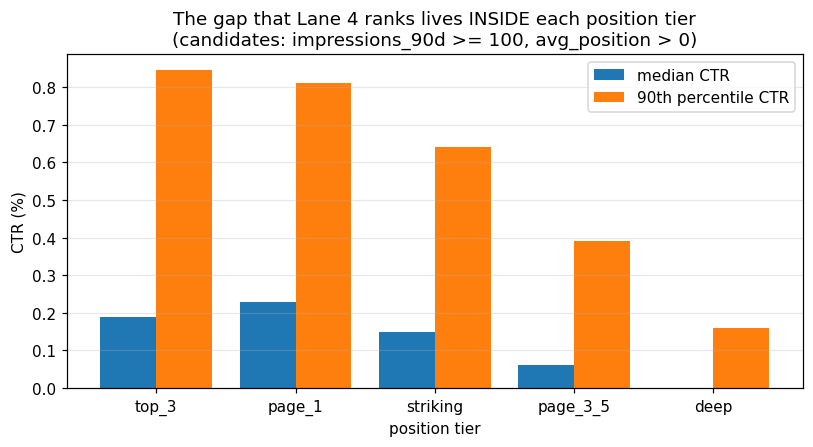

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(TIER_ORDER))
ax.bar(x - 0.2, summary["median_ctr_pct"], width=0.4, label="median CTR")
ax.bar(x + 0.2, summary["p90_ctr_pct"],   width=0.4, label="90th percentile CTR")
ax.set_xticks(x); ax.set_xticklabels(TIER_ORDER)
ax.set_ylabel("CTR (%)"); ax.set_xlabel("position tier")
ax.set_title("The gap that Lane 4 ranks lives INSIDE each position tier\n"
             f"(candidates: impressions_90d >= {VISIBLE_MIN_IMPRESSIONS}, avg_position > 0)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

**Read — and this is the number the whole lane rests on.** Median CTR falls the way you would expect once
you leave page one (0.23% on `page_1`, 0.15% `striking`, 0.06% `page_3_5`, 0.00% `deep`), which is exactly
why comparing two pages' raw CTR without adjusting for position is meaningless — the "common mistake"
the lane guide warns about for Lane 4.

But position tier explains only **~5.6%** of the variation in CTR between pages. Around **94%** of the
difference sits *between pages at the same position tier*, where the 90th-percentile page earns roughly
**3.5x** the median page's CTR on `page_1` and **4.5x** on `top_3`. That residual is the thing worth
ranking, and it is far too tangled — position, volume, intent, content type, client template — for a single
hand-written threshold. That is my answer to "why not just an if-statement."

One thing I did not expect and will not smooth over: **`top_3` has a *lower* median CTR (0.19%) than
`page_1` (0.23%)**, and a higher zero-click share. The tidy CTR-curve story is not clean in this slice.
I do not yet know why — plausible candidates are brand or navigational queries sitting at rank 1–3 with
tiny click intent, a measurement window artefact, or client mix. Explaining that is ML-06 work
(a signal audit), not something to assert now.

### Number 3 — the size of the prize, and how concentrated it is

In [7]:
# A deliberately transparent first look at "under-capture": how far below its OWN tier's median
# a page sits. This is a look, not my baseline - the real baseline (ML-07) will also condition on
# impression band and intent, and will carry reason codes.
cand = candidates.copy()
cand["tier_median_ctr"] = cand.groupby("position_tier")["ctr"].transform("median")
cand["ctr_gap_pct_points"] = cand["tier_median_ctr"] - cand["ctr"]

under = cand[cand["ctr_gap_pct_points"] > 0].copy()
under["missed_clicks_90d"] = under["impressions_90d"] * under["ctr_gap_pct_points"] / 100

total_gap = under["missed_clicks_90d"].sum()
actual_clicks = cand["clicks_90d"].sum()

print(f"Candidate pages below their OWN position tier's median CTR : {len(under):,} "
      f"({len(under)/len(cand)*100:.1f}% of candidates)")
print()
print(f"If each of them merely reached its tier median CTR, that is  : {total_gap:,.0f} extra clicks / 90d")
print(f"Clicks those candidate pages actually earned in 90d          : {actual_clicks:,.0f}")
print(f"The gap as a share of clicks actually earned                 : {total_gap/actual_clicks*100:.1f}%")
print()
for k in (20, 50, 500):
    top_k = under.nlargest(k, "missed_clicks_90d")
    print(f"  top {k:>3} pages by gap hold {top_k['missed_clicks_90d'].sum():>8,.0f} of it "
          f"({top_k['missed_clicks_90d'].sum()/total_gap*100:4.1f}% of the whole gap)")

Candidate pages below their OWN position tier's median CTR : 10,307 (46.8% of candidates)

If each of them merely reached its tier median CTR, that is  : 52,243 extra clicks / 90d
Clicks those candidate pages actually earned in 90d          : 481,752
The gap as a share of clicks actually earned                 : 10.8%

  top  20 pages by gap hold    5,941 of it (11.4% of the whole gap)
  top  50 pages by gap hold   10,115 of it (19.4% of the whole gap)
  top 500 pages by gap hold   29,555 of it (56.6% of the whole gap)


**Read:** 46.8% of candidate pages sit below the median of their own position tier — that alone is not
interesting, since half of anything sits below its median. What *is* interesting is the shape once you weight
by exposure: the arithmetic gap is worth **~52,200 clicks per 90 days, about 10.8%** of what these pages
actually earned, and **the top 50 pages hold 19.4% of it while the top 500 hold 56.6%**.

That concentration is the argument for this being a *ranking* problem rather than a dashboard. A reviewer
working 20 pages a week cannot touch 10,307 pages — but a good ordering puts a disproportionate share of the
available upside inside the handful of slots they do have. It is also the reason precision@K is the right
metric: the tail is irrelevant to the decision.

**What this number is not.** It is an arithmetic ceiling, not a forecast. It assumes a page *could* reach its
tier median, which nobody has shown. I am using it to size the opportunity and justify seven weeks of work —
not to promise 52,000 clicks to anyone.

### A secondary signal I am scoping *out* of week 1, on purpose

In [8]:
eng = candidates[candidates["sessions_90d"] > 0]
print(f"Candidates with any GA4 sessions      : {len(eng):,}")
print(f"  median sessions_90d                 : {eng['sessions_90d'].median():.0f}")
print(f"  median engagement_rate (%)          : {eng['engagement_rate'].median():.2f}")
thin = eng[eng["sessions_90d"] >= 10]
print(f"Candidates with >= 10 sessions in 90d : {len(thin):,} "
      f"({len(thin)/len(candidates)*100:.1f}% of candidates)")
print(f"  median engagement_rate (%)          : {thin['engagement_rate'].median():.2f}")
print()
print("Engagement is thin here: half the candidate pages see ~14 sessions in 90 days, and the")
print("median engagement_rate is 0 until a volume filter is applied. So the 'engagement' half of")
print("Lane 4 needs the warehouse daily table and a minimum-volume rule before it can carry weight.")
print("Week 1 scope = the CTR half. Engagement enters as a guard-rail, not as the headline.")

Candidates with any GA4 sessions      : 22,006
  median sessions_90d                 : 14
  median engagement_rate (%)          : 0.00
Candidates with >= 10 sessions in 90d : 12,801 (58.2% of candidates)
  median engagement_rate (%)          : 1.05

Engagement is thin here: half the candidate pages see ~14 sessions in 90 days, and the
median engagement_rate is 0 until a volume filter is applied. So the 'engagement' half of
Lane 4 needs the warehouse daily table and a minimum-volume rule before it can carry weight.
Week 1 scope = the CTR half. Engagement enters as a guard-rail, not as the headline.


## 4. Careful words: what I can and can't claim

### What this work will be able to say
- **Observed.** "Across 22,006 visible pages from 30 pseudonymized clients, CTR varied by position tier, and
  most of the variation in CTR sat between pages *within* the same tier." That is a measurement of this
  snapshot. I can defend every digit of it.
- **Directional.** "Pages with high impressions and a CTR well below their position-tier peers *appear* to be
  the most promising review candidates." Appear. In this data. Under my thresholds.
- **Decision-support.** "Under a client-grouped split, my ranking put N of its top 20 pages into the group
  that [defined outcome], versus M for a transparent rule baseline." A comparison against a stated baseline,
  on a stated metric, with the split design named — or the honest report that it did not beat the rule.
- **Policy, owned out loud.** Every cutoff in this notebook — 100 impressions, 20 pages a week, "below the
  tier median" — is a choice I made, not a fact I found. I will show what changes when I move them.

### What this work will never be able to say
- **Not causal.** I cannot say a rewritten title *caused* more clicks. There is no experiment here, no
  control group, no random assignment — only a snapshot of what already happened. "Refresh this and it will
  recover" is the sentence I am forbidding myself now, in writing, so I cannot drift into it in week 7.
- **Not a claim about Google.** Nothing here reveals a ranking factor or "predicts Google." I observe
  outcomes on 32 clients' content; I never see the algorithm.
- **Not a claim about AI search visibility.** `ai_sessions_90d` counts click-throughs from AI tools. It is
  not citations, not AI rankings, not "being understood by an LLM" — and in this slice it is sparse enough
  that I will not build a classifier on it.
- **Not "low CTR means the title is bad."** Low CTR is a symptom with many causes: query intent, SERP
  features eating the click, brand queries, seasonality, a competitor's snippet, or measurement noise on a
  low-volume page. My output ranks pages *worth a human look*; the human still decides what is wrong.
- **Not proof that a page is under-performing.** Half of any population is below its own median. That is
  arithmetic, not evidence. The evidence has to come from the volume filter, the comparison group, and the
  top-20 read-through.
- **Not generalisable beyond this panel.** 32 clients, one trailing 90-day window, one content pipeline. I
  will say "in this dataset" and mean it.

### Leakage discipline, declared before I have anything to lose
Named now so I cannot rationalise it later.

In [9]:
NEVER_FEATURES = {
    "trend_pct":        "label source - trend_direction is computed from it (data dictionary rule 2)",
    "trend_direction":  "label source - is_declining_label = (trend_direction == 'down')",
    "content_id":       "pseudonym - grouping/joins only, never a feature",
    "client_id":        "pseudonym - used for GROUPED SPLITS only, never a feature",
    "provider_used":    "generation metadata, not an observable search signal",
    "model_used":       "generation metadata, not an observable search signal",
}
TARGET_INPUTS = {
    "clicks_90d":      "numerator of the observed quantity being ranked",
    "impressions_90d": "denominator, and the volume filter - context, not a free feature",
    "ctr":             "the observed rate itself - it IS the target side, never also an input",
}
print("Columns I am banning from the feature set, and why:")
for c, why in NEVER_FEATURES.items():
    print(f"  {c:18s} -> {why}")
print()
print("Columns that sit on the TARGET side (so they can never quietly become features):")
for c, why in TARGET_INPUTS.items():
    print(f"  {c:18s} -> {why}")
print()

banned = set(NEVER_FEATURES) | set(TARGET_INPUTS)
candidate_features = [c for c in df.columns if c not in banned]
print(f"Columns left as candidate features (to be audited in ML-04/ML-06): {len(candidate_features)}")
print(" ", ", ".join(candidate_features))
print()

# Guard-rails, asserted rather than promised.
assert "trend_pct" not in candidate_features and "trend_direction" not in candidate_features, \
    "LEAKAGE: the label source got into the feature list"
assert "client_id" not in candidate_features, "client_id must be a split key, not a feature"
print("OK - label-source and identifier guards pass.")

# Product decision flags must be absent from this dataset by design. Verify, do not assume.
PRODUCT_FLAGS = ["health_score", "priority_score", "action_type", "refresh_tier",
                 "needs_ctr_fix", "is_quick_win"]
present = [c for c in PRODUCT_FLAGS if c in df.columns]
print(f"Product decision flags present in the data: {present if present else 'none - as designed'}")
print("  (if one ever appears, it is background or a baseline to beat - never a feature.)")
print()

# Public-safe check: nothing in scope can name a client, a domain, a URL, or a query.
UNSAFE_HINTS = ["url", "domain", "title", "query", "keyword_text", "client_name", "email"]
risky = [c for c in df.columns if any(h in c.lower() for h in UNSAFE_HINTS)]
print(f"Columns whose name hints at raw private text: {risky if risky else 'none'}")
print("Sample of the id format that WILL appear in outputs (pseudonyms only):")
print(" ", df["content_id"].iloc[0], "|", df["client_id"].iloc[0])

Columns I am banning from the feature set, and why:
  trend_pct          -> label source - trend_direction is computed from it (data dictionary rule 2)
  trend_direction    -> label source - is_declining_label = (trend_direction == 'down')
  content_id         -> pseudonym - grouping/joins only, never a feature
  client_id          -> pseudonym - used for GROUPED SPLITS only, never a feature
  provider_used      -> generation metadata, not an observable search signal
  model_used         -> generation metadata, not an observable search signal

Columns that sit on the TARGET side (so they can never quietly become features):
  clicks_90d         -> numerator of the observed quantity being ranked
  impressions_90d    -> denominator, and the volume filter - context, not a free feature
  ctr                -> the observed rate itself - it IS the target side, never also an input

Columns left as candidate features (to be audited in ML-04/ML-06): 35
  search_volume, competition, competition_l

**One flag I am raising on my own candidate list.** The 35 columns above are *candidates*, not a feature
set — and three of them already look suspect. `impressions_last_30d`, `clicks_last_30d` and
`sessions_last_30d` sit *inside* the same trailing-90-day window my quantity of interest is measured over,
so they partly contain their own answer. `impressions_prev_30d` / `clicks_prev_30d` / `sessions_prev_30d`
(days 31–60 back) are the safer half of that pair. Window alignment is the first thing the ML-04 data
contract has to settle; I am writing the suspicion down now so the audit has something to check rather than
starting from a blank page.

**Missingness note, so nothing gets silently encoded.** The data dictionary warns that missing keyword
context follows `content_type` (feedly articles carry no keyword data at all) and that `word_count` is blank
for 7,699 rows. A blind `fillna(0)` would therefore write "this is a feedly article" into my features under a
different name and I would never see it. When I impute in ML-04 I will add explicit `has_*` flags and check
missingness per `content_type` first.

**And one more.** `scroll_rate` and `ai_traffic_pct` can legitimately exceed 100 because numerator and
denominator come from different measurement systems. If I ever see a "400% engagement" headline in my own
output, that is my bug, not a discovery.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only, verified in the cell above
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

**Provisional, and I mean provisional.** Lane can be confirmed or changed until the end of Week 4. The thing
most likely to move me: if the ML-06 signal audit shows the within-tier CTR spread is mostly explained by
client template and intent mix rather than anything a reviewer can act on, then Lane 4's ranked queue has no
customer, and Lane 1 (signal analysis) is the honest place for that finding to live.

**Next up (ML-03):** turn this frame into a formal ML task — comparison group definition, the exact
leakage-safe target, the transparent baseline to beat, and the split design written down before any model
is trained.